In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

# 1. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load the MNIST dataset (train and test loaders)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:47<00:00, 208kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 92.0kB/s]
100%|██████████| 1.65M/1.65M [00:09<00:00, 177kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.92MB/s]


Starting Optimizer Comparison...

--- Training with SGD (lr=0.01) ---
   Epoch 1/10 completed | Accuracy: 94.99%
   Epoch 2/10 completed | Accuracy: 96.26%
   Epoch 3/10 completed | Accuracy: 96.99%
   Epoch 4/10 completed | Accuracy: 97.39%
   Epoch 5/10 completed | Accuracy: 97.55%
   Epoch 6/10 completed | Accuracy: 97.68%
   Epoch 7/10 completed | Accuracy: 97.79%
   Epoch 8/10 completed | Accuracy: 97.84%
   Epoch 9/10 completed | Accuracy: 97.92%
   Epoch 10/10 completed | Accuracy: 98.01%
Final Test Accuracy for SGD (lr=0.01): 98.01%

--- Training with SGD with Momentum (lr=0.01, p=0.9) ---
   Epoch 1/10 completed | Accuracy: 97.00%
   Epoch 2/10 completed | Accuracy: 97.52%
   Epoch 3/10 completed | Accuracy: 97.57%
   Epoch 4/10 completed | Accuracy: 98.07%
   Epoch 5/10 completed | Accuracy: 98.11%
   Epoch 6/10 completed | Accuracy: 97.99%
   Epoch 7/10 completed | Accuracy: 98.21%
   Epoch 8/10 completed | Accuracy: 98.16%
   Epoch 9/10 completed | Accuracy: 98.30%
   Epoch

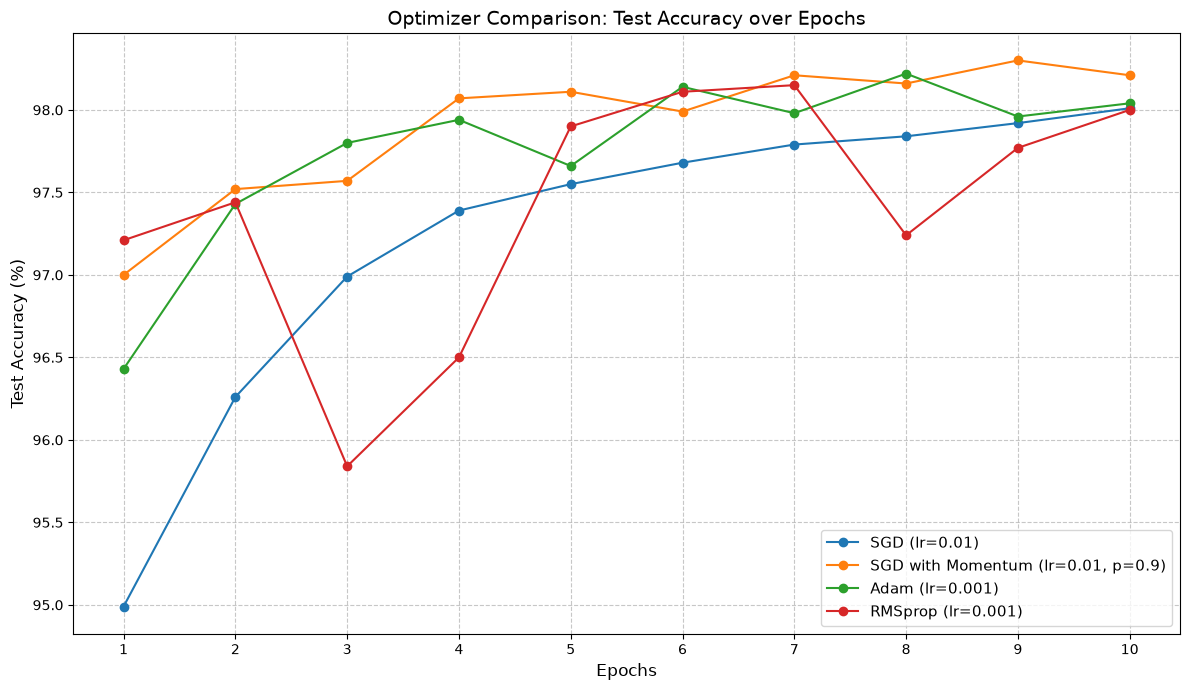

In [5]:
import copy
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Define a function to create a fresh model
# We must re-initialize the model for each optimizer so they start from scratch,
# otherwise an optimizer would just continue training an already-trained model.
def create_model():
    model = nn.Sequential(
        nn.Flatten(), # <--- Adds this to flatten the 28x28 image into a 784 vector
        nn.Linear(784, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 10) # 10 classes for MNIST
    )
    return model.to(device)

# Define the Loss Function
criterion = nn.CrossEntropyLoss()

# 2. Define the optimizers we want to compare
# A dictionary mapping the optimizer name to a function that initializes it
optimizers_dict = {
    "SGD (lr=0.01)": lambda params: optim.SGD(params, lr=0.01),
    "SGD with Momentum (lr=0.01, p=0.9)": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    "Adam (lr=0.001)": lambda params: optim.Adam(params, lr=0.001),
    "RMSprop (lr=0.001)": lambda params: optim.RMSprop(params, lr=0.001)
}

# 3. Training Loop for Comparison
epochs = 10
results = {}

print("Starting Optimizer Comparison...\n")

for opt_name, opt_func in optimizers_dict.items():
    print(f"--- Training with {opt_name} ---")
    
    model = create_model()
    optimizer = opt_func(model.parameters())
    
    test_accuracies = []
    
    for epoch in range(epochs):
        # Training Phase
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
        # Evaluation Phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        acc = 100 * correct / total
        test_accuracies.append(acc)
        print(f"   Epoch {epoch+1}/{epochs} completed | Accuracy: {acc:.2f}%")
    print(f"Final Test Accuracy for {opt_name}: {test_accuracies[-1]:.2f}%\n")
    results[opt_name] = test_accuracies

# 4. Plotting the Results
plt.figure(figsize=(12, 7))

for opt_name, accuracies in results.items():
    plt.plot(range(1, epochs + 1), accuracies, marker='o', label=opt_name)

plt.title('Optimizer Comparison: Test Accuracy over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, epochs + 1))
plt.tight_layout()
plt.show()